In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from numpy import random

from InflGame.adaptive.visualization import Shell
import InflGame.utils.general as general
import InflGame.domains.rd as rd


## Resource distribution (beta)

In [4]:
#The resource points
bin_points=np.linspace(.001, .999, 100)





#resource parmaters
resource_parameters=[2,2] #alpha,beta

#Resource distribution
resource_distribution1=rd.resource_distribution_choice(bin_points=bin_points,resource_type='beta',resource_parameters=resource_parameters)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution1)
ax.set_box_aspect(1)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
plt.close()

## Resource distribution (Gaussian sym)

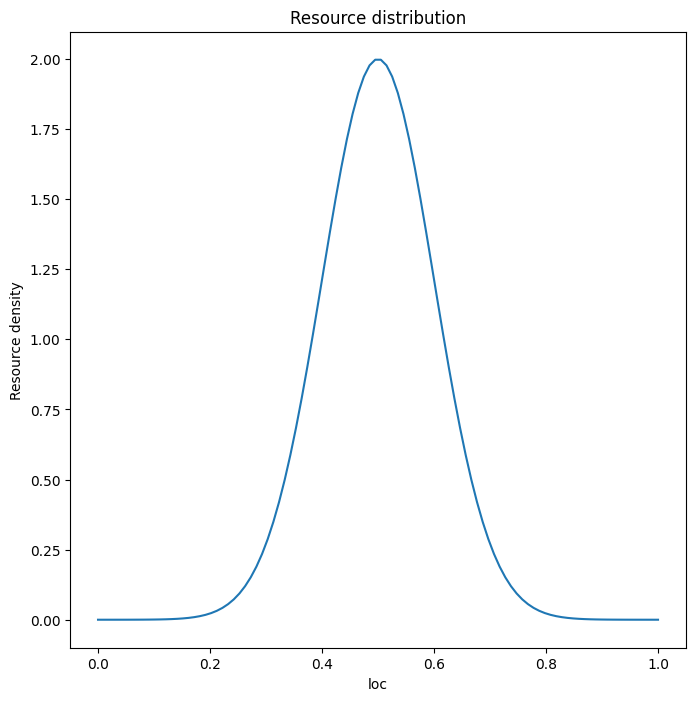

In [5]:
#The resource points
bin_points=np.linspace(.0001, 0.9999, 100)
 
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.5-.0/2,.5+.0/2],[1,1]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution2=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution2)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.show()


## Resource distribution (Gaussian asym)

In [6]:
#The resource points
bin_points=np.linspace(.001, .999, 100)
 
#Resource parameters
resource_parameters_gaussian_asym=[[.1,.1],[.25,.75],[1,.6]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution3=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian_asym)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution3)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()

## Resource distribution (Noisy)

In [7]:
#The resource points
random.seed(1)
bin_points=np.linspace(.001, .999, 100)

#smoothing kernal (resource parameter)
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth
y=np.abs(random.uniform(low=0,high=1,size=100)+random.normal(loc=.5,scale=.1,size=100))

#Resource distribution
resource_distribution4=smooth(y,box_pts=20)
domain=bin_points

#Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_box_aspect(1)
ax.plot(domain,resource_distribution4)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
#fig.savefig('1d_bimodal_noisy.svg',bbox_inches='tight')
plt.close()

## Resource distribution (uniform)

In [8]:
#The resource points
bin_points=np.linspace(.0001, .9999, 100)
 
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.1,.5],[1,1]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution5=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution5)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()

In [9]:
#The resource points
bin_points=np.linspace(.0001, .9999, 100)

resource_distribution6=np.array([1]*len(bin_points))

#Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_box_aspect(1)
ax.plot(domain,resource_distribution6)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
plt.close()

In [10]:
# bin_points=np.array([0,1])


# resource_distribution7=np.array([10,10])

# #Plot
# fig, ax = plt.subplots(figsize=(12, 8))
# ax.vlines(bin_points, 0, resource_distribution7, colors='b', lw=5)
# ax.set_box_aspect(1)
# ax.scatter(bin_points,resource_distribution7)
# plt.title('Resource distribution')
# plt.xlabel('loc')
# plt.ylabel('Resource density')


## Setup:The enviroment and adapative enviroment

The cell below sets up the outer shell for visualizing the the adapative enviroment. 

In [11]:

domain_type='1d'
resource_distribution=resource_distribution2
mean=np.dot(bin_points,resource_distribution)/np.sum(resource_distribution) #mean of the resource distribution




num_agents=3 #number of agents
#int_agents_pos=general.agent_position_setup(num_agents=num_agents,setup_type='paper_default',domain_type=domain_type,domain_bounds=0)
int_agents_pos=torch.tensor([.4,.55,.6]) #initial agent positions

infl_configs={"infl_type":"gaussian"} # influence type of the agents


parameters=general.agent_parameter_setup(num_agents=num_agents,infl_type=infl_configs["infl_type"],setup_type="initial_symmetric_setup",reach=.1) # parameters impacting agents reach (their std)
#parameters_custom=np.array([[.1,.2,.3,...]]) #needs to be length num_players


time_steps=5000# number steps for the adaptive dynamics


vis=Shell(num_agents=num_agents,agents_pos=int_agents_pos,parameters=parameters,resource_distribution=resource_distribution,bin_points=bin_points, 
infl_configs = infl_configs, learning_rate_type= 'gradient_magnitude', learning_rate= [.001, .0001, 500], time_steps=time_steps,
fp= 0, infl_cshift= False, cshift = 0, infl_fshift= False, Q = None,
domain_type = '1d', domain_bounds = [0, 1], resource_type = 'na', domain_refinement = 10,
tolerance = 10**-12, tolerated_agents = None,ignore_zero_infl= True)


vis.setup_adaptive_env()
vis.field.gradient_ascent()
og_pos_matrix=vis.field.pos_matrix
og_grad_matrix=vis.field.grad_matrix
vis.agents_pos=int_agents_pos.clone()
vis.field.agents_pos=int_agents_pos.clone()

        

#(0.158184517)


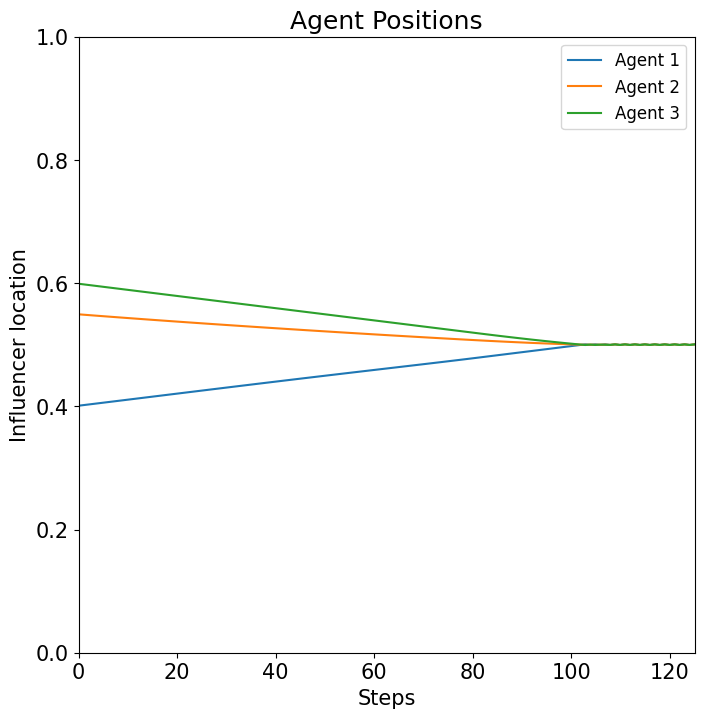

In [12]:
vis.pos_plot()

In [13]:
resource_distribution_type="multi_modal_gaussian_distribution_1D"
alpha_current=.5
alpha_st=0
alpha_end = 1
varying_parameter_type='mean'
fixed_parameters_lst=[resource_parameters_gaussian[0],resource_parameters_gaussian[2]]
num_points=100


resource_parameters,alpha=general.resource_parameter_setup(resource_distribution_type=resource_distribution_type,varying_parameter_type=varying_parameter_type,alpha_st=alpha_st, alpha_end=alpha_end, fixed_parameters_lst=fixed_parameters_lst,alpha_num_points=num_points)


In [14]:
from InflGame.adaptive.bifurcation_analysis import BifurcationEnv

In [15]:
bif_field=BifurcationEnv(vis.num_agents,vis.agents_pos,vis.parameters,vis.resource_distribution,vis.bin_points,
              vis.infl_configs,vis.learning_rate_type,vis.learning_rate,vis.time_steps,fp= 0, infl_cshift= False, cshift = 0, infl_fshift= False, Q = None,
              domain_type = '1d', domain_bounds = [0, 1], resource_type = 'na', domain_refinement = 10,
              tolerance = 10**-8, tolerated_agents = None,ignore_zero_infl= True)
bif_field.setup_adaptive_env()

In [16]:
import hickle as hkl
"""
test=bif_field.find_second_order_bifs(bin_points=bin_points,
                                      fixed_parameters_lst=fixed_parameters_lst,
                                      resource_distribution_type=resource_distribution_type,
                                      alpha_st=alpha_st,
                                      alpha_end=alpha_end,
                                      num_points=num_points,
                                      varying_parameter_type=varying_parameter_type,
                                      parallel=True,
                                      max_workers=8,
                                      batch_size=4,
                                      agents_pos=torch.Tensor([.4,.5,.6]),
                                      time_steps=20000,
                                      learning_rate_p=[.0001,.01,5000],
                                      direct_method=True,)

test['final_parameters']=np.array(test['final_parameters'])
hkl.dump(test, 'gaussian_bif.hkl')
"""

"\ntest=bif_field.find_second_order_bifs(bin_points=bin_points,\n                                      fixed_parameters_lst=fixed_parameters_lst,\n                                      resource_distribution_type=resource_distribution_type,\n                                      alpha_st=alpha_st,\n                                      alpha_end=alpha_end,\n                                      num_points=num_points,\n                                      varying_parameter_type=varying_parameter_type,\n                                      parallel=True,\n                                      max_workers=8,\n                                      batch_size=4,\n                                      agents_pos=torch.Tensor([.4,.5,.6]),\n                                      time_steps=20000,\n                                      learning_rate_p=[.0001,.01,5000],\n                                      direct_method=True,)\n\ntest['final_parameters']=np.array(test['final_parameters'])\nhkl

In [17]:
def bif_results_processing(test_results):
    """
    Process bifurcation results to ensure all dictionaries have uniform list lengths.
    
    Pads shorter lists with their last value. If a list is empty, uses the corresponding
    sigma_star value as padding.
    
    :param test_results: Dictionary containing 'sigma_star' and 'final_parameters'
    :return: Dictionary with processed 'unstable_flip' and 'stable_flip' as 2D arrays
    """
    sigma_star_list = test_results['sigma_star']
    final_parameters = test_results['final_parameters']
    
    # Find the maximum length across all lists
    max_unstable_len = 0
    max_stable_len = 0
    
    for param_dict in final_parameters:
        if isinstance(param_dict, dict):
            max_unstable_len = max(max_unstable_len, len(param_dict.get('unstable_flip', [])))
            max_stable_len = max(max_stable_len, len(param_dict.get('stable_flip', [])))
    
    # Initialize output arrays
    num_params = len(final_parameters)
    unstable_flip_array = np.zeros((num_params, max(max_unstable_len, 1)))
    stable_flip_array = np.zeros((num_params, max(max_stable_len, 1)))
    
    # Process each parameter's dictionary
    for i, (param_dict, sigma_star) in enumerate(zip(final_parameters, sigma_star_list)):
        if isinstance(param_dict, dict):
            # Process unstable_flip
            unstable_list = param_dict.get('unstable_flip', [])
            if len(unstable_list) == 0:
                # If empty, fill with sigma_star
                unstable_flip_array[i, :] = sigma_star
            else:
                # Copy existing values
                unstable_flip_array[i, :len(unstable_list)] = unstable_list
                # Pad with last value
                if len(unstable_list) < max_unstable_len:
                    unstable_flip_array[i, len(unstable_list):] = unstable_list[-1]
            
            # Process stable_flip
            stable_list = param_dict.get('stable_flip', [])
            if len(stable_list) == 0:
                # If empty, fill with sigma_star
                stable_flip_array[i, :] = sigma_star
            else:
                # Copy existing values
                stable_flip_array[i, :len(stable_list)] = stable_list
                # Pad with last value
                if len(stable_list) < max_stable_len:
                    stable_flip_array[i, len(stable_list):] = stable_list[-1]
        else:
            # Handle non-dict entries (error cases)
            unstable_flip_array[i, :] = sigma_star
            stable_flip_array[i, :] = sigma_star
    
    return {
        'sigma_star': sigma_star_list,
        'unstable_flip': unstable_flip_array,
        'stable_flip': stable_flip_array,
        'max_unstable_len': max_unstable_len,
        'max_stable_len': max_stable_len
    }

# Process the bifurcation results
"""
test_processed = bif_results_processing(test)
hkl.dump(test_processed,'gaussian_bif.hkl')
"""

"\ntest_processed = bif_results_processing(test)\nhkl.dump(test_processed,'gaussian_bif.hkl')\n"

In [23]:
test_processed=hkl.load('gaussian_bif.hkl')

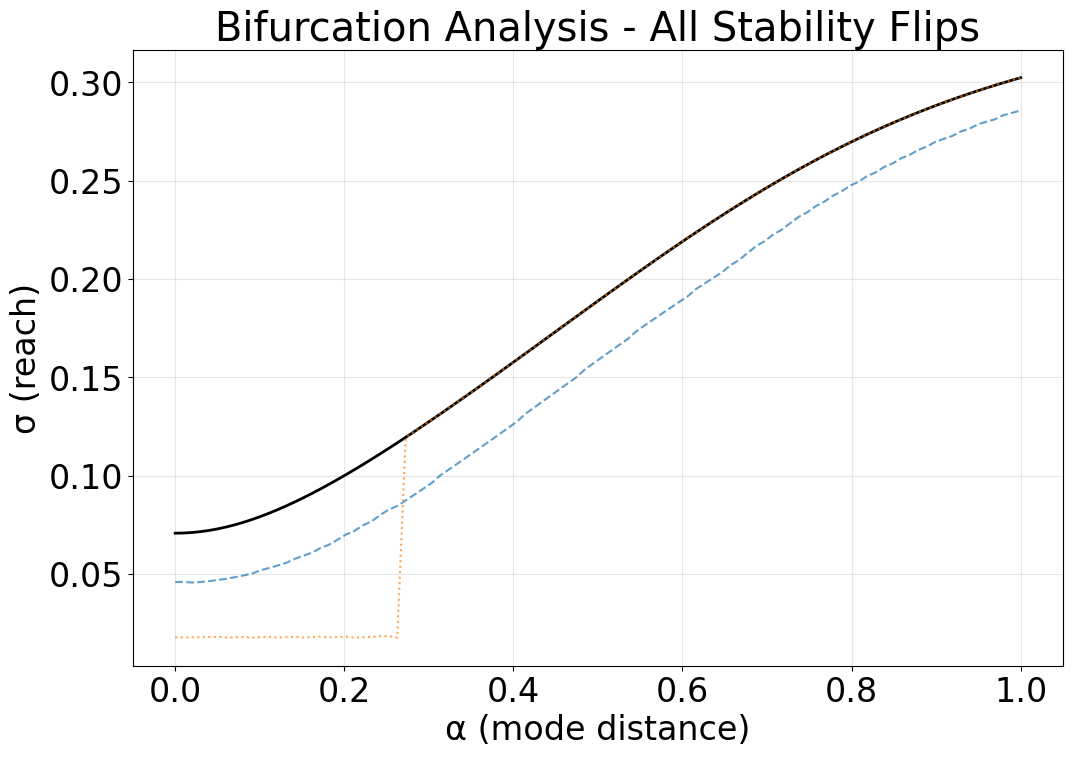

In [24]:
# Example: Plot the processed data
plt.figure(figsize=(12, 8))
plt.plot(alpha[:770], test_processed['sigma_star'][:770], label='σ* (exact)', linewidth=2, color='black')

# Plot all columns of unstable flips
for i in range(0,1):
    plt.plot(alpha[:770], test_processed['unstable_flip'][:, i][:770], 
             label=f'Unstable flip {i+1}', linestyle='--', alpha=0.7)

# Plot all columns of stable flips
for i in range(0,1):
    plt.plot(alpha[:770], test_processed['stable_flip'][:, i][:770], 
             label=f'Stable flip {i+1}', linestyle=':', alpha=0.7)

plt.xlabel('α (mode distance)')
plt.ylabel('σ (reach)')

plt.title('Bifurcation Analysis - All Stability Flips')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
"""
test2=bif_field.find_third_order_bifurcations_refined(int_position=torch.tensor([.51,.55,.6]),
                                                second_order_bif= test_processed['unstable_flip'][:, 0],
                                                guess_distance=.1,
                                                sig_edge=0.01,
                                                num_refinements=20,
                                                learning_rate_p={'min':.00001,'max':.0001,'period':100,'min_simulated':.01},
                                                resource_distribution_type=resource_distribution_type,
                                                alpha_st=alpha[0],
                                                alpha_end=alpha_end,
                                                alpha_num_points=len(alpha),
                                                varying_parameter_type=varying_parameter_type,
                                                fixed_parameters_lst=[resource_parameters_gaussian[0],resource_parameters_gaussian[2]],
                                                parallel=True,
                                                max_workers=8,
                                                batch_size=4,
                                                time_steps=40000,
                                                learning_rate_type='gradient_magnitude')

test_processed['cycles_end']=np.array(test2)         
hkl.dump(test_processed,'gaussian_bif.hkl')
"""

In [26]:

import matplotlib.patches as mpatches
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator
from typing import List, Tuple, Dict, Optional
import matplotlib.figure

from InflGame.utils import data_management
def first_order_bifurcation_plot(infl_type: str = 'gaussian',
                                 alpha_st: float = 0,
                                 alpha_end: float = 1,
                                 test_processed = None,
                                 alpha_values = None,
                                 cutoff_index = None,
                                 title_ads: List[str] = [],
                                 save: bool = False,
                                 name_ads: List[str] = [],
                                 font = {'default_size': 24, 'cbar_size': 16, 'title_size': 34, 'legend_size': 12, 'table_size':15,'label_size':10,'font_family': 'sans-serif',},
                                 save_types: List[str] = ['.png', '.svg'],
                                 paper_figure: dict= {'paper':False,'section':'3_2_6','figure_id':'bif_diag'}
                                ) -> matplotlib.figure.Figure:
    r"""
        Plots the first-order bifurcation for agents over a range of alpha values (resource parameters) via func:`jacobian_stability_fast`. 
        
        Now supports both original format (Gaussian) and new beta format with processed stability flips.

        **Gaussian example**

        .. figure:: examples/first_order.png
            :scale: 75 %

            This is a first order bifurcations plot for 5 players using symmetric Gaussian influence kernels.
                

        :param agent_parameter_instance: Parameters for the influence function.
        :type agent_parameter_instance: Union[List[float], np.ndarray]
        :param resource_distribution_type: Type of resource distribution.
        :type resource_distribution_type: str
        :param resource_entropy: Whether to calculate resource entropy.
        :type resource_entropy: bool
        :param infl_entropy: Whether to calculate influence entropy.
        :type infl_entropy: bool
        :param alpha_current: Current alpha value.
        :type alpha_current: float
        :param alpha_st: Starting value of alpha.
        :type alpha_st: float
        :param alpha_end: Ending value of alpha.
        :type alpha_end: float
        :param varying_paramter_type: Type of varying parameter (e.g., 'mean').
        :type varying_paramter_type: str
        :param fixed_parameters_lst: List of fixed parameters.
        :type fixed_parameters_lst: Optional[List[float]]
        :param name_ads: Additional names for saved files.
        :type name_ads: List[str]
        :param title_ads: Additional titles for the plot.
        :type title_ads: List[str]
        :param save_types: File types to save the plot.
        :type save_types: List[str]
        :param test_processed: Processed test results with 'unstable_flip', 'stable_flip', and optionally 'cycles_end'
        :type test_processed: Optional[dict]
        :param alpha_values: Alpha values array
        :type alpha_values: Optional[np.ndarray]
        :param cutoff_index: Index to cutoff the data
        :type cutoff_index: Optional[int]

        :return: The generated plot figure.
        :rtype: matplotlib.figure.Figure
        """


                             
    
    font['font.family'] = font.get('font_family', 'sans-serif')
    cbar_font_size= font.get('cbar_size', 12)
    default_font_size = font.get('default_size', 18)
    title_font_size = font.get('title_size', 14)
    legend_font_size = font.get('legend_size', 12)
    table_font_size = font.get('table_size',12)
    label_font_size = font.get('label_size',10)
    mpl.rcParams.update({'font.size': default_font_size, 'font.family': font['font.family']})
    mpl.rcParams['legend.fontsize'] = legend_font_size
    
    fig,ax=plt.subplots(figsize=(24, 16))
    ax.set_box_aspect(1)
    
    # Apply font settings
    plt.rcParams.update({'font.size': font['default_size'], 'font.family': font['font_family']})
    
    # Determine which format we're using
    # Original Gaussian case: using test['final_parameters'] as arrays
    if alpha_values is None:
            raise ValueError("alpha_values must be provided when using test_processed")
        
    if cutoff_index is None:
            cutoff_index = len(alpha_values)
    
    alpha = alpha_values[:cutoff_index]
    y = test_processed['sigma_star'][:cutoff_index]
    z = test_processed['unstable_flip'][:cutoff_index, 0]
    
    # Check if cycles_end exists in test_processed
    has_cycles = 'cycles_end' in test_processed and test_processed['cycles_end'] is not None
    
    # Plot sigma_star and unstable flip
    ax.plot(alpha, y, label=r'$\sigma^{*}_0$ exact', color='black')
    ax.fill_between(alpha, y, max(max(y), .3), where=(alpha <= alpha_end), color='#87CEEB', alpha=0.5)  # Sky blue for symmetric Nash
    
    if infl_type == 'beta':
        # If stable flip exists, add it
        if test_processed['max_stable_len'] > 0:
            w = test_processed['stable_flip'][:cutoff_index, 0]
            ax.plot(alpha, w, label=r'$\sigma^{*}_1$ est.', color='black', linestyle='dashdot')
            ax.fill_between(alpha, w, y, where=(alpha >= alpha_st), color='#FF6B6B', alpha=0.5)  # Coral red for 2-1
            ax.fill_between(alpha, z, w, where=(alpha >= alpha_st), color='#9370DB', alpha=0.5)  # Medium purple for 1-1-1
        else:
            ax.fill_between(alpha, 0, z, where=(alpha >= alpha_st), color='#FF6B6B', alpha=0.5)  # Coral red for 2-1
        ax.plot(alpha, z, label=r'$\sigma^{*}_2$ est.', color='black', linestyle='--')
        
        # Fill regions with improved colors
        if has_cycles:
            # Handle both 1D and 2D arrays for cycles_end
            cycles_data = test_processed['cycles_end']
            if isinstance(cycles_data, np.ndarray) and cycles_data.ndim > 1:
                w = cycles_data[:cutoff_index].flatten() if cycles_data.shape[1] == 1 else cycles_data[:cutoff_index, 0]
            else:
                w = np.array(cycles_data)[:cutoff_index]
            ax.plot(alpha, w, label=r'$\sigma^{*}_3$ est.', color='black', linestyle='dotted')
            ax.fill_between(alpha, w, z, where=(alpha >= alpha_st), color='#FFD700', alpha=0.5)  # Gold for cycle
            ax.fill_between(alpha, 0, w, where=(alpha >= alpha_st), color='#FF6B6B', alpha=0.5)  # Coral red for 2-1
        
        
    else:
        # Gaussian case: Fill regions with improved colors
        ax.fill_between(alpha, y, z, where=(alpha >= alpha_st), color='#9370DB', alpha=0.5)
        ax.plot(alpha, z, label=r'$\sigma^{*}_1$ est.', color='black', linestyle='--')
        
        if has_cycles:
            # Handle both 1D and 2D arrays for cycles_end
            cycles_data = test_processed['cycles_end']
            if isinstance(cycles_data, np.ndarray) and cycles_data.ndim > 1:
                w = cycles_data[:cutoff_index].flatten() if cycles_data.shape[1] == 1 else cycles_data[:cutoff_index, 0]
            else:
                w = np.array(cycles_data)[:cutoff_index]
            ax.plot(alpha, w, label=r'$\sigma^{*}_2$ est.', color='black', linestyle='dotted')
            ax.fill_between(alpha, w, z, where=(alpha >= alpha_st), color='#FFD700', alpha=0.5)  # Gold for cycle
            ax.fill_between(alpha, 0, w, where=(alpha >= alpha_st), color='#FF6B6B', alpha=0.5)  # Coral red for 2-1
        
    
    plt.ylim(0, max(max(y), .3))
    
    # Legend patches with improved colors
    red_p = mpatches.Patch(color='#FF6B6B', alpha=0.5, label='2-1 or 1-2')
    yellow_p = mpatches.Patch(color='#FFD700', alpha=0.5, label='cycle')
    purple_p = mpatches.Patch(color='#9370DB', alpha=0.5, label='1-1-1')
    blue_p = mpatches.Patch(color='#87CEEB', alpha=0.5, label=r'sym nash')
    
    old_handles, labels = ax.get_legend_handles_labels()
    
    # Conditionally add legend patches based on what's plotted
    legend_handles = [blue_p]
    if infl_type == 'beta':
        legend_handles.append(red_p)
        legend_handles.append(purple_p)
        if has_cycles:
            legend_handles.append(yellow_p)
    else:
        legend_handles.append(purple_p)
        if has_cycles:
            legend_handles.append(yellow_p)
            legend_handles.append(red_p)
    
    plt.legend(handles=legend_handles + old_handles)
    plt.ylabel("$\sigma$ (reach)", fontsize=font['default_size'])
    plt.xlabel(r"$\alpha$ (mode distance)", fontsize=font['default_size'])
    
    title = r"$(\alpha,\sigma)$ $x^{*}$ stability bifurication for " + str(vis.num_agents) + " players"
    if len(title_ads) > 0:
        for title_additon in title_ads:
            title = title + " " + title_additon
    plt.title(title, fontsize=font['title_size'])
    plt.xlim(alpha_st, alpha_end) 
    plt.close()
    if save==True:
        file_names=data_management.data_final_name({'data_type':'plot',"plot_type":'bif_diagram','domain_type':vis.domain_type,'num_agents':vis.num_agents,'section':paper_figure['section'],'figure_id':paper_figure.get('figure_id','bif_diagram')},name_ads=name_ads,save_types=save_types,paper_figure=paper_figure['paper'])
        for file_name in file_names:
            fig.savefig(file_name,bbox_inches='tight')
        
    return fig


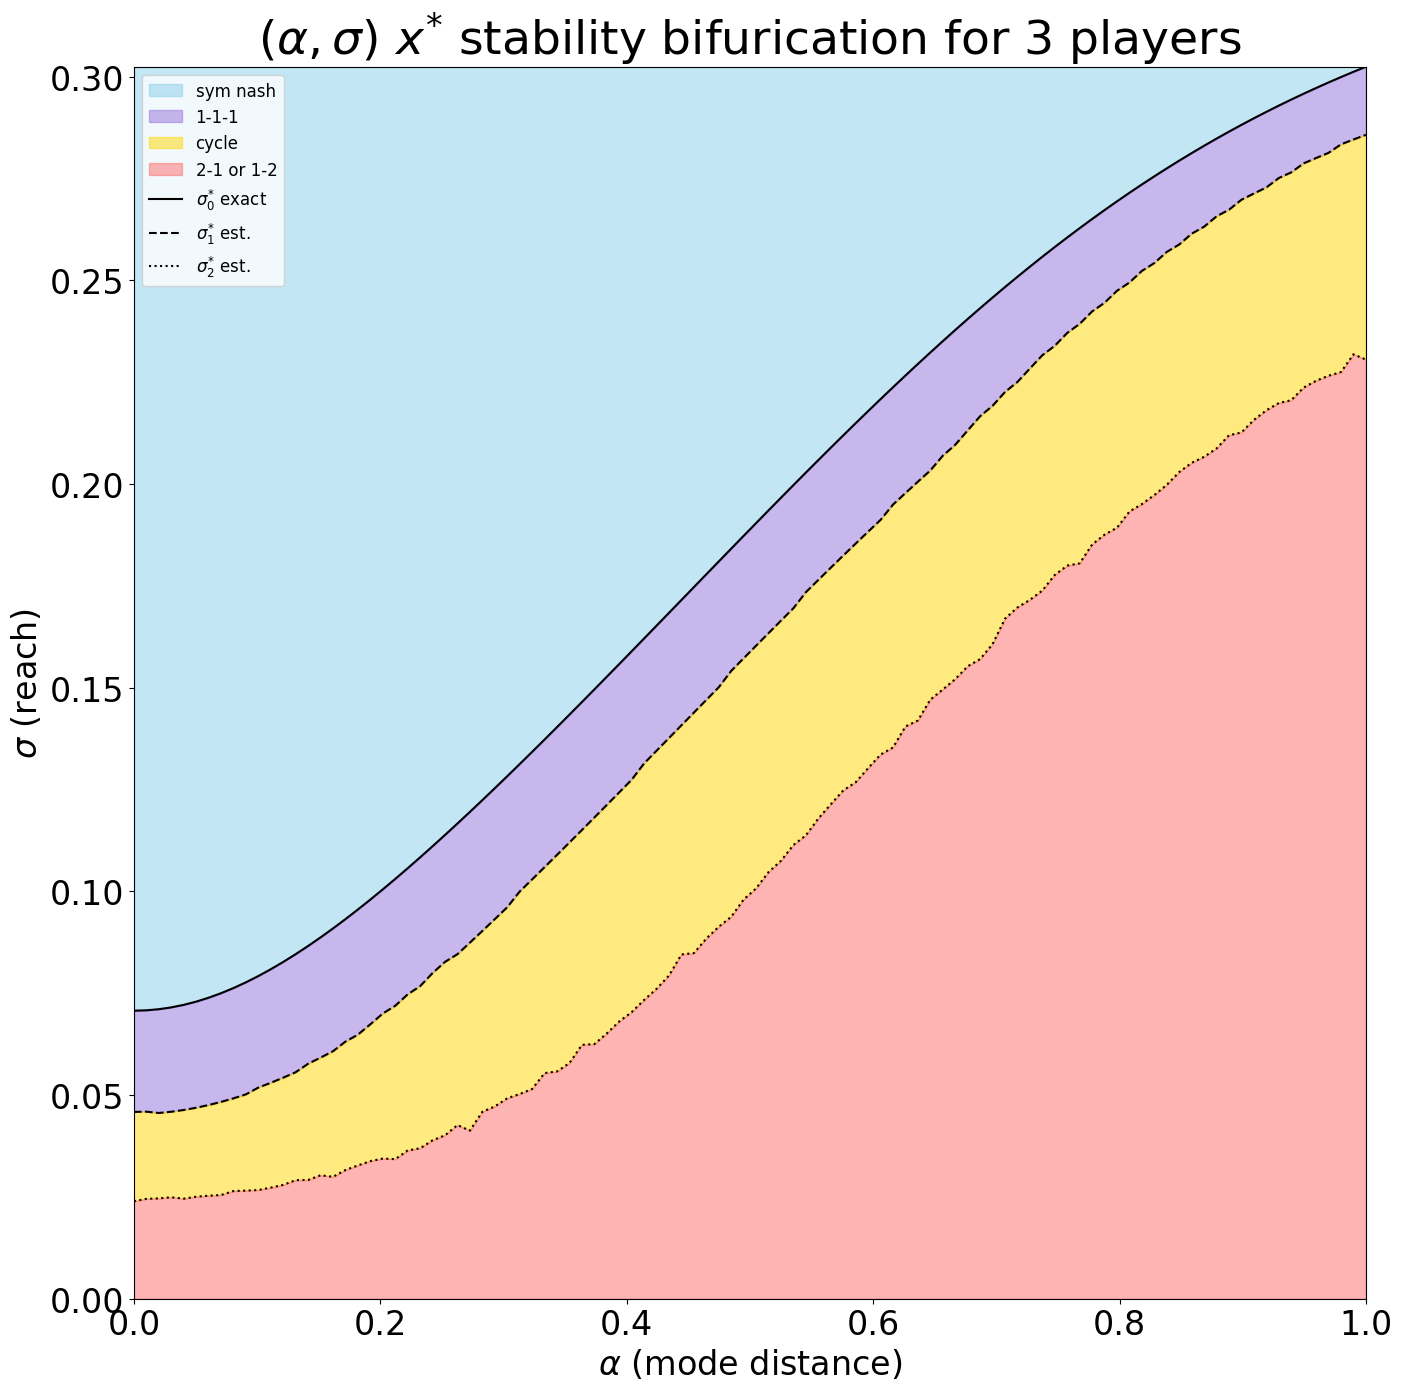

In [27]:
first_order_bifurcation_plot(alpha_st=0,
                             alpha_end=alpha[-1],
                             test_processed=test_processed,
                             alpha_values=alpha,
                             save=True,
                             paper_figure={'paper':True,'section':'3_2_6','figure_id':'fig6_2'})